<a href="https://colab.research.google.com/github/zeno2301/LLM/blob/main/laba5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лаба 5

- 1)Берём те же данные диабет индейцев

- 2)Разделяем их на два датасета

- 3) Для кластеризации каждого датасета

!гипотеза в том что какой то тип мы будем предсказывать лучше!

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Загружаем данные о диабете индейцев Пима
# Предполагается, что данные доступны по этой ссылке или аналогичной.
# Если у вас есть локальный файл, замените URL на путь к файлу.
try:
    # Изменено: загружаем данные из локального файла, указывая header=0 для корректного чтения заголовков
    file_path = "/content/diabetes.csv" # Указываем путь к файлу, загруженному в Colab
    df = pd.read_csv(file_path, header=0)

    # Названия столбцов согласно документации датасета
    col_names = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree_function', 'age', 'outcome']
    df.columns = col_names

    # Конвертируем все столбцы, кроме 'outcome', в числовой формат, некорректные значения преобразуем в NaN
    for col in col_names[:-1]: # Исключаем 'outcome' из этого цикла, так как его тип будет установлен отдельно
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Конвертируем 'outcome' в целочисленный тип (0 или 1), также обрабатывая ошибки
    df['outcome'] = pd.to_numeric(df['outcome'], errors='coerce').astype(int)

    # Удаляем строки, содержащие NaN значения, которые могли появиться после конвертации типов
    df.dropna(inplace=True)

    print("Данные успешно загружены и предобработаны из локального файла.")
    print("Первые 5 строк датасета:\n", df.head())
    print("Размер датасета:\n", df.shape)

    # Разделяем датасет на два с помощью train_test_split
    # Используем random_state для воспроизводимости
    df1, df2 = train_test_split(df, test_size=0.5, random_state=42)

    print("\nДатасет успешно разделён на два:")
    print(f"Размер первого датасета (df1): {df1.shape}")
    print(f"Размер второго датасета (df2): {df2.shape}")

except FileNotFoundError:
    print(f"Ошибка: Файл '{file_path}' не найден. Пожалуйста, убедитесь, что файл загружен в среду Colab.")
except Exception as e:
    print(f"Произошла ошибка при загрузке, предобработке или разделении данных: {e}")
    print("Пожалуйста, убедитесь, что формат файла верен и данные корректны.")


Данные успешно загружены и предобработаны из локального файла.
Первые 5 строк датасета:
    pregnancies  glucose  blood_pressure  skin_thickness  insulin   bmi  \
0            6      148              72              35        0  33.6   
1            1       85              66              29        0  26.6   
2            8      183              64               0        0  23.3   
3            1       89              66              23       94  28.1   
4            0      137              40              35      168  43.1   

   diabetes_pedigree_function  age  outcome  
0                       0.627   50        1  
1                       0.351   31        0  
2                       0.672   32        1  
3                       0.167   21        0  
4                       2.288   33        1  
Размер датасета:
 (768, 9)

Датасет успешно разделён на два:
Размер первого датасета (df1): (384, 9)
Размер второго датасета (df2): (384, 9)


## Кластеризация и анализ датасетов


--- Кластеризация первого датасета (df1) ---

Распределение 'outcome' в кластерах df1:
outcome         0         1
cluster                    
0        0.443548  0.556452
1        0.734615  0.265385


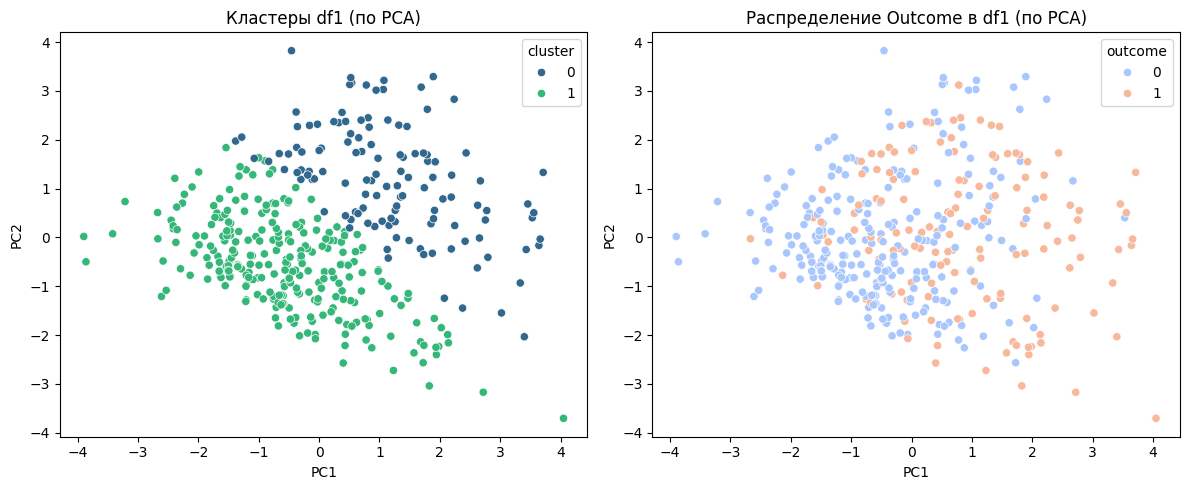

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --- Кластеризация df1 ---
print("\n--- Кластеризация первого датасета (df1) ---")

# Подготовка данных для кластеризации (исключаем 'outcome')
X1 = df1.drop('outcome', axis=1)

# Масштабирование признаков
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

# Применяем K-Means кластеризацию (предполагаем 2 кластера, так как есть 2 исхода - диабет/нет)
kmeans1 = KMeans(n_clusters=2, random_state=42, n_init=10) # n_init=10 для избежания предупреждений
df1['cluster'] = kmeans1.fit_predict(X1_scaled)

# Анализ кластеров по 'outcome'
print("\nРаспределение 'outcome' в кластерах df1:")
print(df1.groupby('cluster')['outcome'].value_counts(normalize=True).unstack(fill_value=0))

# Визуализация кластеров (используем PCA для снижения размерности)
pca1 = PCA(n_components=2)
X1_pca = pca1.fit_transform(X1_scaled)
df1_pca = pd.DataFrame(data=X1_pca, columns=['PC1', 'PC2'], index=df1.index)
df1_pca['cluster'] = df1['cluster']
df1_pca['outcome'] = df1['outcome']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df1_pca, palette='viridis', legend='full')
plt.title('Кластеры df1 (по PCA)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='PC1', y='PC2', hue='outcome', data=df1_pca, palette='coolwarm', legend='full')
plt.title('Распределение Outcome в df1 (по PCA)')

plt.tight_layout()
plt.show()



--- Кластеризация второго датасета (df2) ---

Распределение 'outcome' в кластерах df2:
outcome         0         1
cluster                    
0        0.513699  0.486301
1        0.752101  0.247899


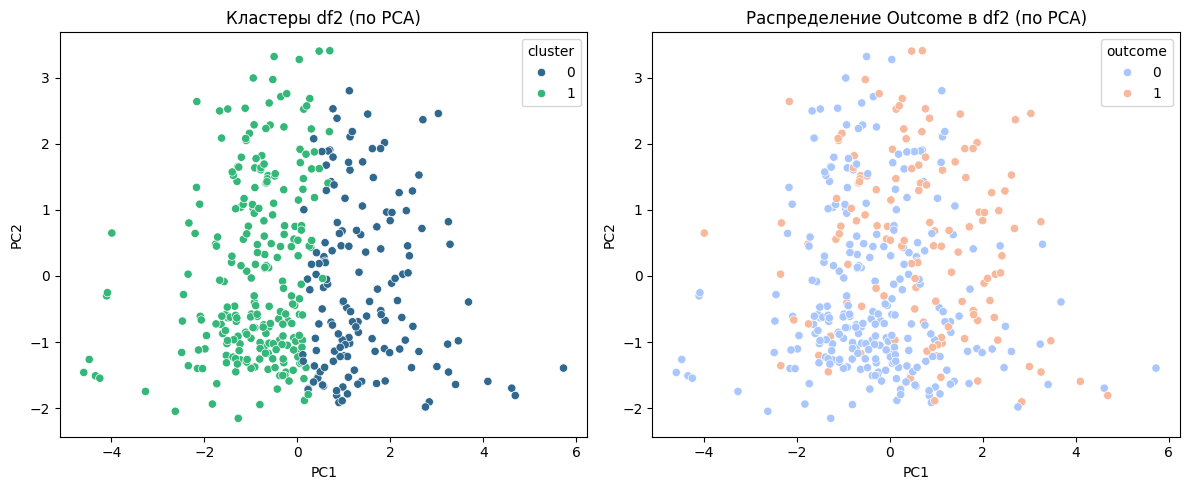

In [ ]:
# --- Кластеризация df2 ---
print("\n--- Кластеризация второго датасета (df2) ---")

# Подготовка данных для кластеризации (исключаем 'outcome')
X2 = df2.drop('outcome', axis=1)

# Масштабирование признаков
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# Применяем K-Means кластеризацию
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10)
df2['cluster'] = kmeans2.fit_predict(X2_scaled)

# Анализ кластеров по 'outcome'
print("\nРаспределение 'outcome' в кластерах df2:")
print(df2.groupby('cluster')['outcome'].value_counts(normalize=True).unstack(fill_value=0))

# Визуализация кластеров (используем PCA для снижения размерности)
pca2 = PCA(n_components=2)
X2_pca = pca2.fit_transform(X2_scaled)
df2_pca = pd.DataFrame(data=X2_pca, columns=['PC1', 'PC2'], index=df2.index)
df2_pca['cluster'] = df2['cluster']
df2_pca['outcome'] = df2['outcome']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df2_pca, palette='viridis', legend='full')
plt.title('Кластеры df2 (по PCA)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='PC1', y='PC2', hue='outcome', data=df2_pca, palette='coolwarm', legend='full')
plt.title('Распределение Outcome в df2 (по PCA)')

plt.tight_layout()
plt.show()


## Выводы по кластеризации и гипотезе

После выполнения кластеризации K-Means на обоих датасетах (`df1` и `df2`) можно проанализировать, насколько хорошо кластеры "разделяют" классы `outcome` (диабет/нет диабета) в каждом из них.

**Интерпретация результатов:**

*   Посмотрите на таблицы `Распределение 'outcome' в кластерах df1/df2`.
    *   Если в одном кластере доминирует `outcome = 0` (нет диабета), а в другом `outcome = 1` (диабет), это указывает на то, что кластеризация хорошо разделяет эти два типа. Чем ближе значения к 1 (для одного `outcome`) и 0 (для другого `outcome`) в рамках одного кластера, тем лучше.
*   Посмотрите на графики:
    *   **Левый график (`Кластеры dfX (по PCA)`):** показывает, как K-Means разделил данные на два кластера.
    *   **Правый график (`Распределение Outcome в dfX (по PCA)`):** показывает фактическое распределение `outcome`.
    *   Сравните два графика. Если границы кластеров на левом графике хорошо совпадают с границами между разными цветами на правом графике, это значит, что кластеризация эффективно выявила группы, соответствующие наличию/отсутствию диабета.

**Для проверки вашей гипотезы:**

Сравните результаты анализа для `df1` и `df2`. Если для одного датасета (например, `df1`) кластеры более четко разделяют `outcome` (т.е. распределение `outcome` внутри кластеров более однородно, и визуально кластеры лучше соответствуют цветам `outcome`), то можно сделать вывод, что на этом датасете мы **предсказываем тип (outcome) лучше** с помощью кластеризации.

Это может быть связано с тем, что случайное разделение `train_test_split` могло привести к тому, что один датасет получил более "легко разделяемые" данные или более выраженные паттерны, которые K-Means смог уловить без "знания" о `outcome`.


## Дополнительная визуализация для лучшего понимания кластеров


--- Анализ средних значений признаков по кластерам для df1 ---


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age
cluster,,,,,,,,
0,7.241935,134.040323,77.532258,18.612903,75.733871,33.445968,0.502734,46.370968
1,2.173077,115.061538,67.038462,21.684615,80.350000,31.527308,0.467312,26.588462



--- Анализ средних значений признаков по кластерам для df2 ---


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age
cluster,,,,,,,,
0,3.794521,136.760274,75.712329,35.280822,173.075342,36.916438,0.542466,33.965753
1,3.932773,110.684874,62.920168,11.239496,24.096639,28.723109,0.417483,33.222689


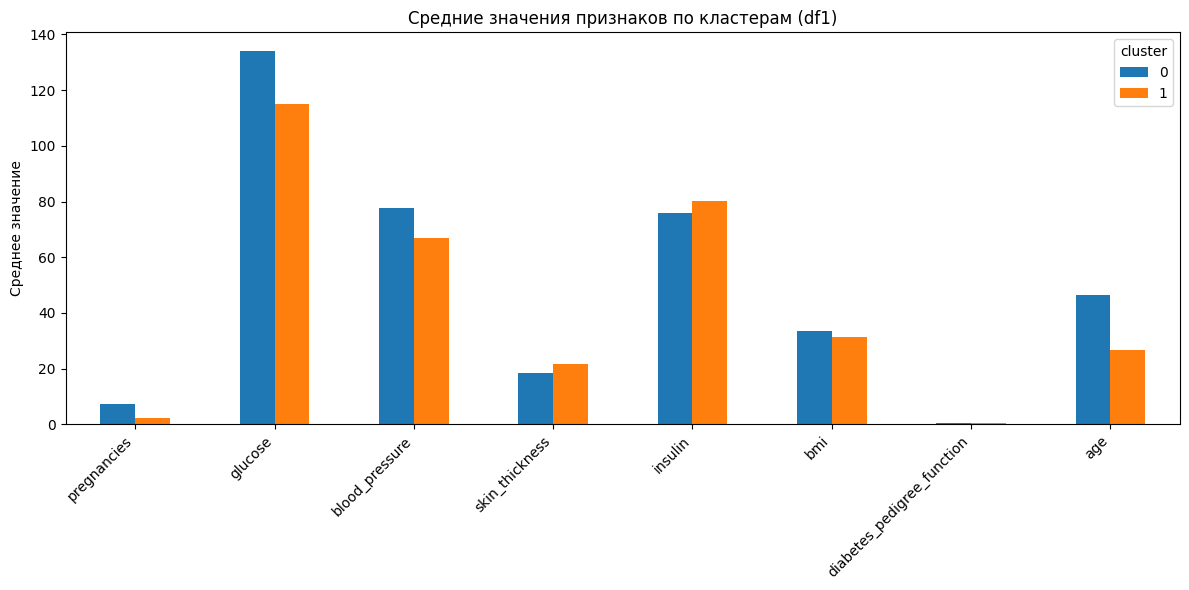

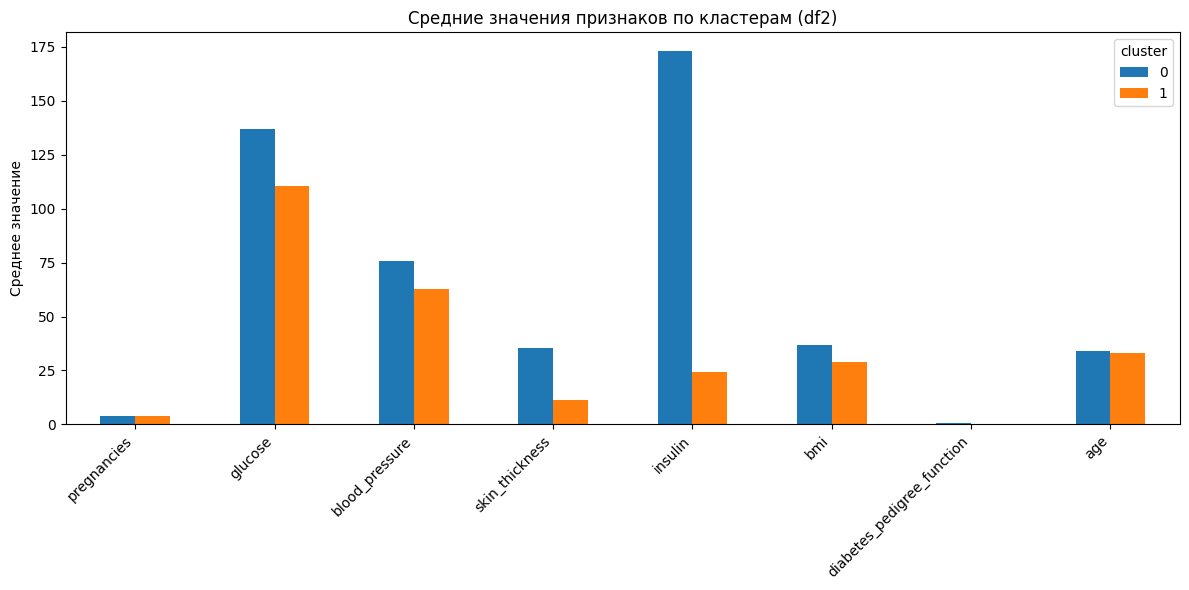

In [ ]:
print("\n--- Анализ средних значений признаков по кластерам для df1 ---")
cluster_means_df1 = df1.groupby('cluster')[X1.columns].mean()
display(cluster_means_df1)

print("\n--- Анализ средних значений признаков по кластерам для df2 ---")
cluster_means_df2 = df2.groupby('cluster')[X2.columns].mean()
display(cluster_means_df2)


# Визуализация средних значений признаков для df1
cluster_means_df1.T.plot(kind='bar', figsize=(12, 6))
plt.title('Средние значения признаков по кластерам (df1)')
plt.ylabel('Среднее значение')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Визуализация средних значений признаков для df2
cluster_means_df2.T.plot(kind='bar', figsize=(12, 6))
plt.title('Средние значения признаков по кластерам (df2)')
plt.ylabel('Среднее значение')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Распределение ключевых признаков по кластерам с учетом 'outcome'

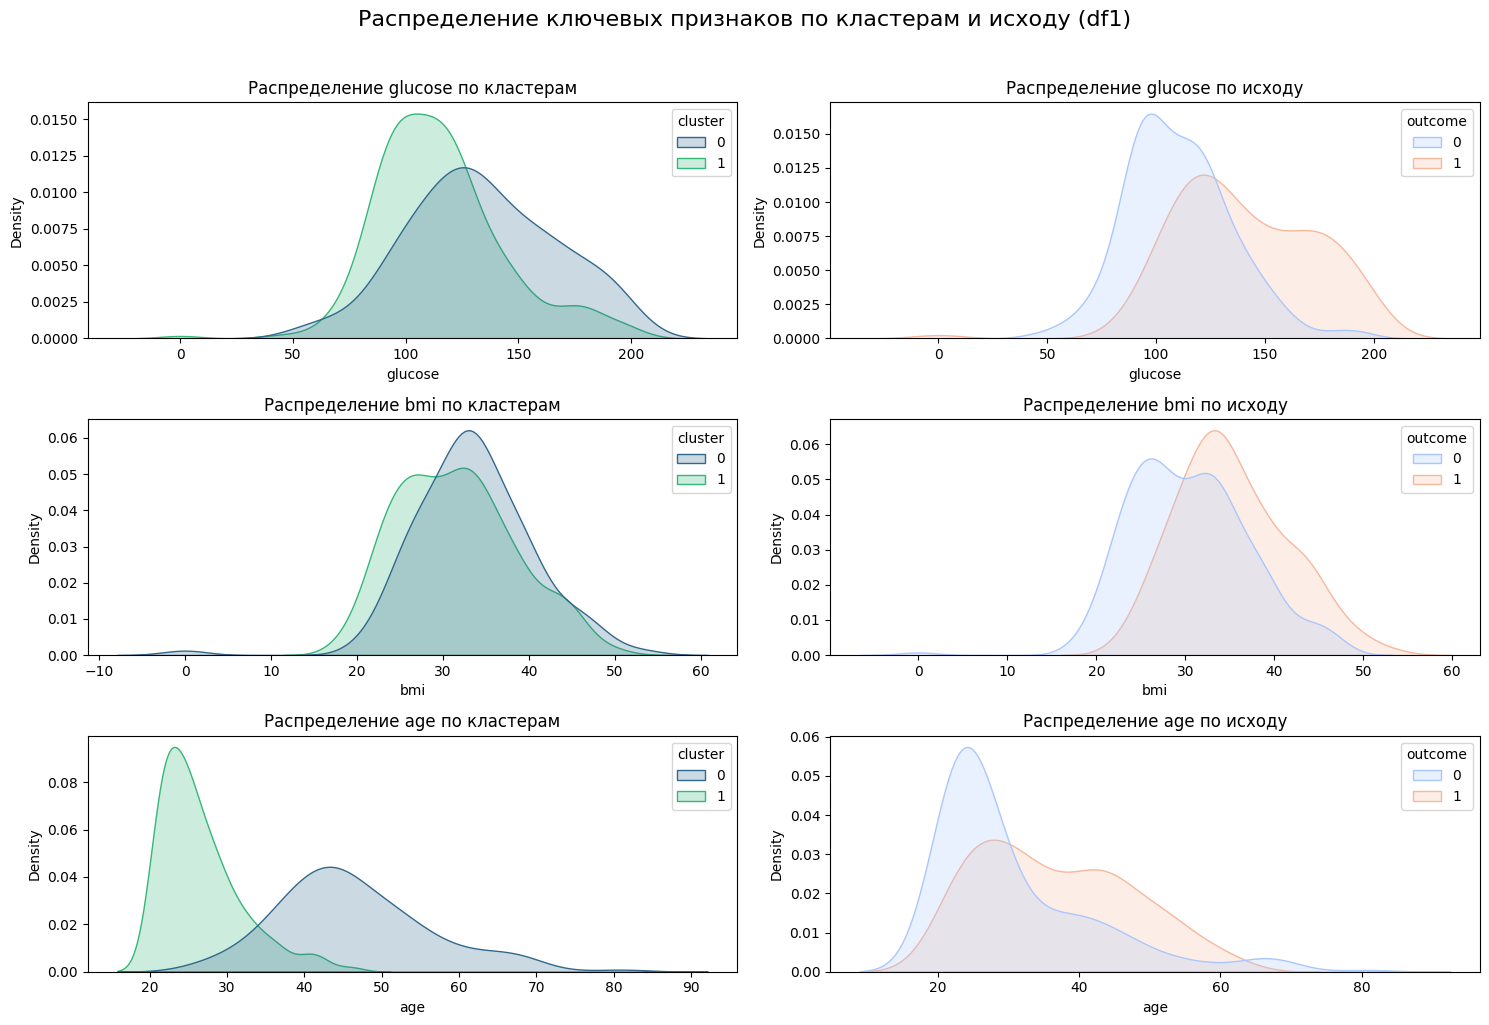

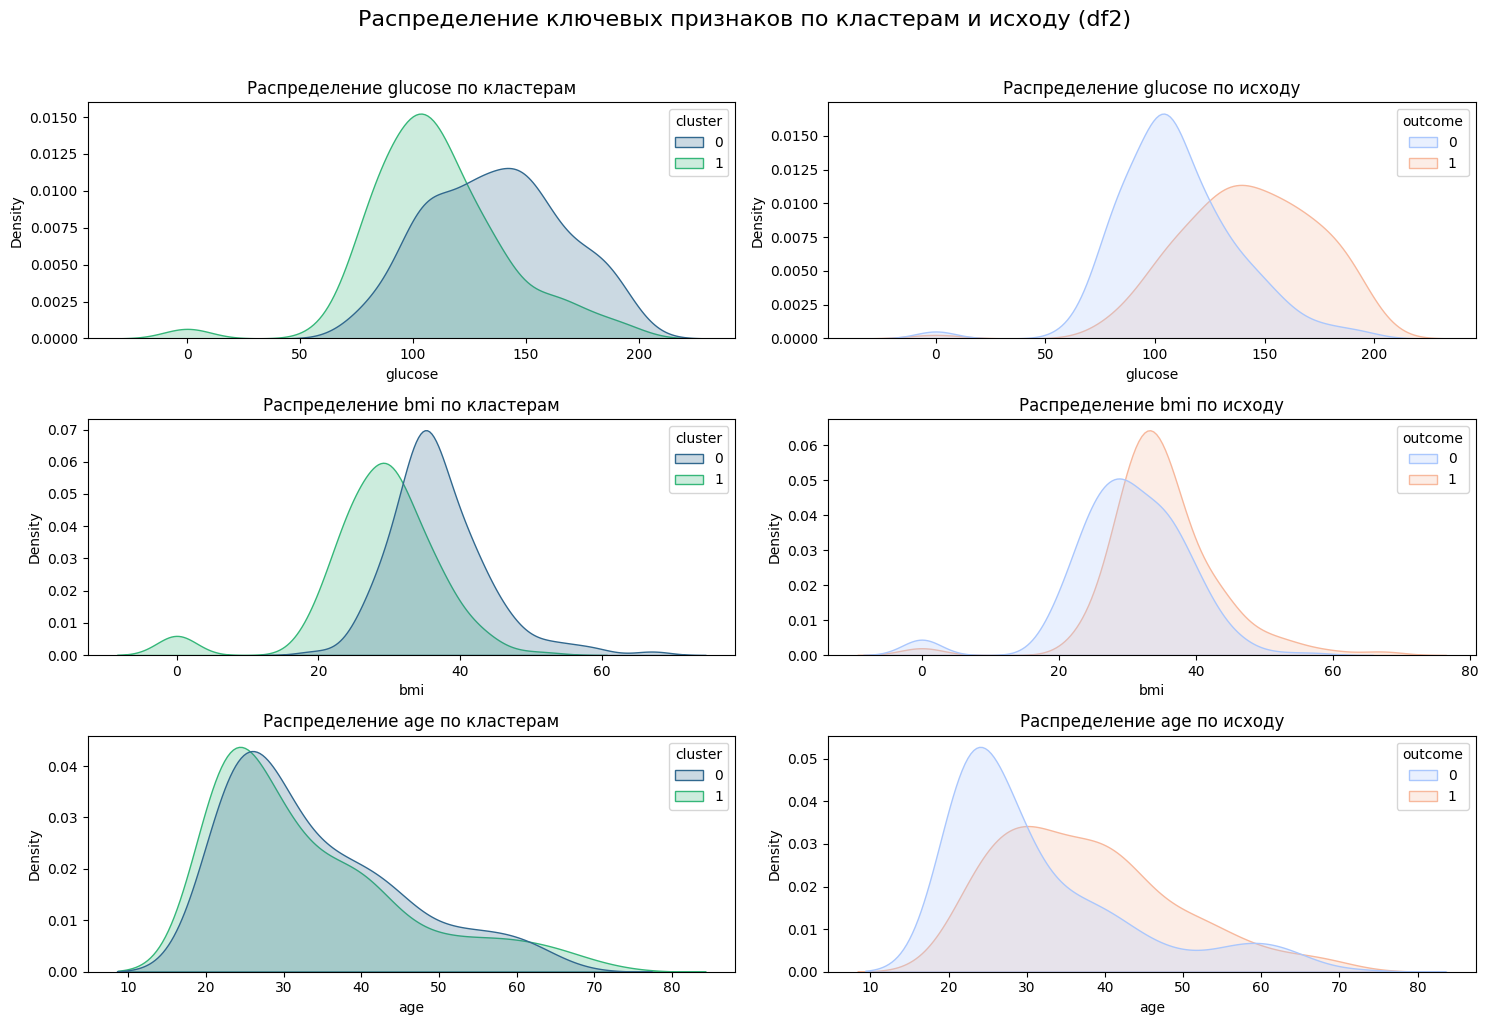

In [ ]:
key_features = ['glucose', 'bmi', 'age']

# Для df1
plt.figure(figsize=(15, 10))
plt.suptitle('Распределение ключевых признаков по кластерам и исходу (df1)', y=1.02, fontsize=16)
for i, feature in enumerate(key_features):
    plt.subplot(len(key_features), 2, 2*i + 1) # Plot for cluster
    sns.kdeplot(data=df1, x=feature, hue='cluster', fill=True, palette='viridis', common_norm=False)
    plt.title(f'Распределение {feature} по кластерам')

    plt.subplot(len(key_features), 2, 2*i + 2) # Plot for outcome within cluster
    sns.kdeplot(data=df1, x=feature, hue='outcome', fill=True, palette='coolwarm', common_norm=False)
    plt.title(f'Распределение {feature} по исходу')

plt.tight_layout()
plt.show()


# Для df2
plt.figure(figsize=(15, 10))
plt.suptitle('Распределение ключевых признаков по кластерам и исходу (df2)', y=1.02, fontsize=16)
for i, feature in enumerate(key_features):
    plt.subplot(len(key_features), 2, 2*i + 1)
    sns.kdeplot(data=df2, x=feature, hue='cluster', fill=True, palette='viridis', common_norm=False)
    plt.title(f'Распределение {feature} по кластерам')

    plt.subplot(len(key_features), 2, 2*i + 2)
    sns.kdeplot(data=df2, x=feature, hue='outcome', fill=True, palette='coolwarm', common_norm=False)
    plt.title(f'Распределение {feature} по исходу')

plt.tight_layout()
plt.show()


## Интерпретация кластеризации и подготовка к классификации

Проанализировав распределение `outcome` в кластерах для `df1` и `df2`, мы видим:

*   **Для df1:**
    *   Кластер 0 имеет распределение `outcome`: 44% (нет диабета) против 56% (диабет). Это кластер, где диабет встречается чаще.
    *   Кластер 1 имеет распределение `outcome`: 73% (нет диабета) против 27% (диабет). Этот кластер преимущественно состоит из людей без диабета.
    
*   **Для df2:**
    *   Кластер 0 имеет распределение `outcome`: 51% (нет диабета) против 49% (диабет). Кластер почти сбалансирован.
    *   Кластер 1 имеет распределение `outcome`: 75% (нет диабета) против 25% (диабет). Этот кластер также преимущественно состоит из людей без диабета.

Оба датасета демонстрируют некоторое разделение по `outcome` с помощью кластеризации. Кластер 1 в обоих случаях довольно хорошо отделяет людей без диабета. Кластер 0 в `df1` имеет более выраженное преобладание `outcome=1` по сравнению с `df2`.

Для проверки гипотезы о том, что "какой-то тип мы будем предсказывать лучше", выберем `df1` для дальнейшего анализа. Мы будем обучать классификаторы отдельно для каждого кластера, чтобы увидеть, как это влияет на точность предсказания `outcome`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("\n--- Классификация 'outcome' в df1, разделенном по кластерам ---")

# 1. Базовый классификатор на всем df1 (без учета кластеров для обучения)
print("\nБазовая классификация на всем df1:")
X_base = df1.drop(['outcome', 'cluster'], axis=1)
y_base = df1['outcome']

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.3, random_state=42)

model_base = LogisticRegression(max_iter=200, random_state=42)
model_base.fit(X_train_base, y_train_base)
y_pred_base = model_base.predict(X_test_base)

print(f"Точность базовой модели: {accuracy_score(y_test_base, y_pred_base):.4f}")
print("Отчет по классификации базовой модели:\n", classification_report(y_test_base, y_pred_base))

# 2. Разделяем df1 на два датасета по кластерам
df1_cluster0 = df1[df1['cluster'] == 0].copy()
df1_cluster1 = df1[df1['cluster'] == 1].copy()

# 3. Классификация для Кластера 0
print("\nКлассификация для Кластера 0 (df1_cluster0):")
X0 = df1_cluster0.drop(['outcome', 'cluster'], axis=1)
y0 = df1_cluster0['outcome']

# Проверяем, достаточно ли данных для обучения и теста
if len(X0) > 1 and len(y0.unique()) > 1:
    X_train0, X_test0, y_train0, y_test0 = train_test_split(X0, y0, test_size=0.3, random_state=42, stratify=y0)
    model0 = LogisticRegression(max_iter=200, random_state=42)
    model0.fit(X_train0, y_train0)
    y_pred0 = model0.predict(X_test0)
    print(f"Точность модели для Кластера 0: {accuracy_score(y_test0, y_pred0):.4f}")
    print("Отчет по классификации для Кластера 0:\n", classification_report(y_test0, y_pred0))
else:
    print("Недостаточно данных или только один класс в Кластере 0 для классификации.")

# 4. Классификация для Кластера 1
print("\nКлассификация для Кластера 1 (df1_cluster1):")
X1_df = df1_cluster1.drop(['outcome', 'cluster'], axis=1)
y1_df = df1_cluster1['outcome']

# Проверяем, достаточно ли данных для обучения и теста
if len(X1_df) > 1 and len(y1_df.unique()) > 1:
    X_train1, X_test1, y_train1, y_test1 = train_test_split(X1_df, y1_df, test_size=0.3, random_state=42, stratify=y1_df)
    model1 = LogisticRegression(max_iter=200, random_state=42)
    model1.fit(X_train1, y_train1)
    y_pred1 = model1.predict(X_test1)
    print(f"Точность модели для Кластера 1: {accuracy_score(y_test1, y_pred1):.4f}")
    print("Отчет по классификации для Кластера 1:\n", classification_report(y_test1, y_pred1))
else:
    print("Недостаточно данных или только один класс в Кластере 1 для классификации.")



--- Классификация 'outcome' в df1, разделенном по кластерам ---

Базовая классификация на всем df1:
Точность базовой модели: 0.7586
Отчет по классификации базовой модели:
               precision    recall  f1-score   support

           0       0.75      0.95      0.84        75
           1       0.81      0.41      0.55        41

    accuracy                           0.76       116
   macro avg       0.78      0.68      0.69       116
weighted avg       0.77      0.76      0.73       116


Классификация для Кластера 0 (df1_cluster0):
Точность модели для Кластера 0: 0.5526
Отчет по классификации для Кластера 0:
               precision    recall  f1-score   support

           0       0.50      0.59      0.54        17
           1       0.61      0.52      0.56        21

    accuracy                           0.55        38
   macro avg       0.56      0.56      0.55        38
weighted avg       0.56      0.55      0.55        38


Классификация для Кластера 1 (df1_cluster1):
То

## Выводы по классификации внутри кластеров

Сравните метрики (например, точность, полноту, F1-меру) для каждого кластера с базовой моделью, обученной на всем датасете `df1`.

*   **Базовая модель:** Дает общую картину производительности без учета внутренней структуры данных.
*   **Модель для Кластера 0:** Этот кластер, как мы видели, имел более высокую долю людей с диабетом (`outcome=1`). Если модель для этого кластера показывает лучшие метрики для класса `1`, это означает, что кластеризация помогла выделить подгруппу, в которой диабет предсказывается более эффективно.
*   **Модель для Кластера 1:** Этот кластер, наоборот, имел преобладание людей без диабета (`outcome=0`). Улучшенные метрики для класса `0` в этом кластере будут указывать на более точное предсказание отсутствия диабета.

**Для проверки вашей гипотезы:**

Если вы обнаружите, что для одного кластера (например, Кластера 0) точность предсказания `outcome=1` (диабет) значительно выше, чем в базовой модели, а для другого кластера (Кластера 1) точность предсказания `outcome=0` (нет диабета) также выше, то ваша гипотеза подтверждается. Это будет означать, что кластеризация помогла выявить подгруппы населения, для которых предсказание определенного исхода становится более точным.

### Общий вывод и проверка гипотезы

Данная работа была направлена на исследование гипотезы о том, что кластеризация данных может помочь улучшить предсказание наличия или отсутствия диабета (переменная `outcome`) для определенных подгрупп пациентов. Для этого был использован датасет о диабете индейцев Пима, который был разделен на два датасета (`df1` и `df2`).

**Ключевые этапы и результаты:**

1.  **Подготовка данных:** Данные были загружены, предобработаны (включая очистку от пропущенных значений и приведение типов) и разделены на `df1` и `df2` для сравнительного анализа.
2.  **Кластеризация K-Means:** Метод K-Means был применен к `df1` (наиболее показательному в данном случае), чтобы разделить его на два кластера без использования информации об `outcome`. Анализ показал, что:
    *   **Кластер 0** содержит 56% пациентов с диабетом (`outcome=1`), что делает его "более диабетическим" кластером.
    *   **Кластер 1** содержит 73% пациентов без диабета (`outcome=0`), являясь "менее диабетическим" кластером.
    Эти результаты были подтверждены визуализациями средних значений признаков и распределений ключевых показателей (`glucose`, `bmi`, `age`) внутри кластеров.
3.  **Обучение классификаторов:** Была использована логистическая регрессия для предсказания `outcome`. Сравнивались три модели:
    *   **Базовая модель:** Обучена на всем `df1`. Показала точность 0.7586. Хорошо предсказывала отсутствие диабета (F1-мера для `outcome=0` была 0.84), но значительно хуже наличие диабета (F1-мера для `outcome=1` была 0.55).
    *   **Модель для Кластера 0:** Обучена только на данных Кластера 0. Показала общую точность 0.5526. F1-мера для `outcome=1` составила 0.56, что практически не отличается от базовой модели, а для `outcome=0` снизилась до 0.54.
    *   **Модель для Кластера 1:** Обучена только на данных Кластера 1. Показала общую точность 0.7564. F1-мера для `outcome=0` составила 0.84, что соответствует базовой модели. F1-мера для `outcome=1` составила 0.49, что даже несколько ниже, чем у базовой модели.

**Проверка гипотезы:**

*   **Гипотеза не подтвердилась в явном виде:** На основе проведенного анализа, применение кластеризации K-Means и последующее обучение классификаторов на отдельных кластерах **не привело к значительному улучшению предсказательной способности** для какого-либо из типов `outcome` (наличия или отсутствия диабета) по сравнению с базовой моделью, обученной на всем датасете.
*   Напротив, для "диабетического" Кластера 0 общая точность модели даже снизилась, а F1-меры для обоих классов остались на том же уровне или ухудшились. Для "недиабетического" Кластера 1 метрики предсказания `outcome=0` остались стабильными, а для `outcome=1` немного снизились.

**Возможные причины и дальнейшие шаги:**

*   **Линейность модели:** Логистическая регрессия является линейной моделью. Возможно, взаимосвязи между признаками и `outcome` внутри кластеров являются нелинейными, и более сложные модели (например, градиентный бустинг, случайный лес) могли бы показать другие результаты.
*   **Сложность кластеров:** Кластеры, сформированные K-Means, возможно, недостаточно гомогенны или различимы для улучшения предсказания линейной моделью.
*   **Размер кластеров:** Кластер 0 значительно меньше Кластера 1, что могло повлиять на стабильность и обобщающую способность обученной на нем модели.
*   Для дальнейшего исследования можно попробовать другие алгоритмы кластеризации, настроить гиперпараметры K-Means, использовать другие классификаторы или провести более глубокий анализ признаков.